![](img/winter.jpg){width=500}

Summer Olympic sports like soccer, basketball, and track & field are among the most widely played and competetive sports in the world largely because they are easily accessible (in that they don't require much equipment or specialized training) and can be played almost anywhere. Winter Olympic sports, on the other hand, feel much more niche. Whenever I watch events like the biathalon or curling, I often think to myself "which countries even play these sports and why are they so good at it?"

My intuition points to two key factors that might determine a country's success at the Winter Olympics: wealth and climate. Thus, for this blog post, I wanted to test my predictions by analyzing countries' historical Winter Olympic performances as a function of their economic resources and geographic climate. In order to conduct this study, I focused on the period from 1992 to 2022 and merged publicly available data on Winter Olympic results with country level GDP per capita (averaged across years), latitude, and population.

Set up

In [2]:
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt

import numpy as np

Loading olympics data

In [3]:
olympics = pd.read_csv('data/winter_olympics_medals.csv')

Cleaning/reshaping

In [4]:
years = [1992, 1994, 1998, 2002, 2006, 2010, 2014, 2018, 2022]

olympics = olympics[olympics["year"].isin(years)].copy()

olympics["total_medals"] = olympics["medal"].isin(["Gold", "Silver", "Bronze"]).astype(int)

olympics = (
    olympics.groupby("noc")["total_medals"]
    .sum()
    .reset_index()
)

olympics = olympics.rename(columns = {"noc": "country"}) #used ChatGPT to help count medals

Loading in gdp data

In [5]:
gdp_og = pd.read_csv('data/gdp_pcap.csv')

Cleaning

In [6]:
years = [str(y) for y in range(1992, 2023)]
gdp_og["gdp_capita"] = gdp_og[years].mean(axis = 1)

gdp_og["gdp_capita"] = gdp_og["gdp_capita"].round(1)

gdp = gdp_og[["geo", "gdp_capita"]].copy()

gdp["geo"] = gdp["geo"].str.upper()
gdp = gdp.rename(columns = {"geo": "country"}) #used ChatGPT to help calculate the range

/tmp/ipykernel_2165636/2176625054.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  gdp_og["gdp_capita"] = gdp_og[years].mean(axis = 1)


Loading in geography data

In [7]:
coord = pd.read_csv('data/country_coord.csv')

Cleaning

In [8]:
coord["abs_latitude"] = coord["Latitude (average)"].abs()

coord["abs_latitude"] = coord["abs_latitude"].round(1)

coord = coord[[
    "Alpha-3 code",
    "abs_latitude"
]].copy()

coord = coord.rename(columns = {"Alpha-3 code": "country"})

Loading in population data

In [9]:
pop = pd.read_csv('data/populations.csv')

Cleaning

In [10]:
years = [str(y) for y in range(1992, 2023)]
pop["population"] = pop[years].mean(axis = 1)

pop["population"] = np.log(pop["population"])

pop = pop[["Country Code", "population"]].copy()

pop = pop.rename(columns = {"Country Code": "country"})

Merging olympics, gdp, coordinates, and population data

In [11]:
data = olympics.copy()

data = data.merge(gdp, on = "country", how = "left")

data = data.merge(coord, on = "country", how = "left")

data = data.merge(pop, on = "country", how = "left")

,country,total_medals,gdp_capita,abs_latitude,population
0,AHO,0,NaN,NaN,NaN
1,ALB,0,9963.7,41.0,14.912183
2,ALG,0,NaN,NaN,NaN
3,AND,0,56551.7,42.5,11.172671
4,ARG,0,24454.9,34.0,17.501291
...,...,...,...,...,...
118,USA,470,59089.2,38.0,19.516777
119,UZB,1,5612.7,41.0,17.138763
120,VEN,0,13415.6,8.0,17.097929
121,YUG,0,NaN,NaN,NaN


Correcting name match issue

In [12]:
names = {
    "BUL": "BGR",
    "CRO": "HRV",
    "DEN": "DNK",
    "GER": "DEU",
    "LAT": "LVA",
    "NED": "NLD",
    "SLO": "SVN",
    "SUI": "CHE",
    "ROC": "RUS",
    "TCH": "CZE"
}

data["country"] = data["country"].replace(names)

data = data[data["country"] != "EUN"] #used ChatGPT to diagnose name matching issue and for help correcting it

Remerging data

In [13]:
data = data.drop(columns = ["gdp_capita", "abs_latitude", "population"]) #ChatGPT suggested to line to fix an error

data = data.merge(gdp, on = "country", how = "left")
data = data.merge(coord, on = "country", how = "left")
data = data.merge(pop, on = "country", how = "left")

data = data.dropna()

,country,total_medals,gdp_capita,abs_latitude,population
1,ALB,0,9963.7,41.0,14.912183
3,AND,0,56551.7,42.5,11.172671
4,ARG,0,24454.9,34.0,17.501291
5,ARM,0,9441.1,40.0,14.930538
7,AUS,22,49723.6,27.0,16.874968
...,...,...,...,...,...
114,TUR,0,19912.9,39.0,18.073077
115,UKR,13,14516.3,49.0,17.668738
117,USA,470,59089.2,38.0,19.516777
118,UZB,1,5612.7,41.0,17.138763


### Wealth

Many Winter Olympic sports require access to equipment, facilities, and specialized training that only the wealthiest individuals could afford. In fact, in an interview with CBS's 60 Minutes, Arthur Liu, father of figure skater Alysa Liu, revealed that he spent between $500K to $1M on his daughter's career. And his experience is far from unique. According to one NBC report, some Winter Olympians pay over $100K a year to sustain their elite training routines.

If success in winter sports is this costly at the individual level, it raises the question: what does the relationship between wealth and performance look like across countries?

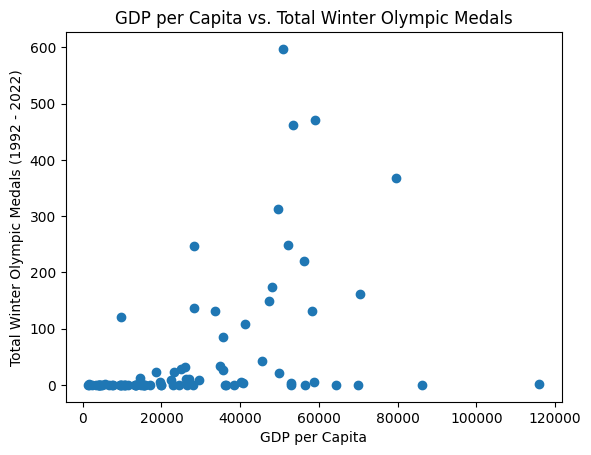

In [15]:
plt.scatter(data["gdp_capita"], data["total_medals"])

plt.xlabel("GDP per Capita")
plt.ylabel("Total Winter Olympic Medals (1992 - 2022)")
plt.title ("GDP per Capita vs. Total Winter Olympic Medals")

plt.show()

In [41]:
highest_gdp = data.loc[data["gdp_capita"].idxmax()]
highest_gdp

country               LUX
total_medals            2
gdp_capita       115905.7
abs_latitude         49.8
population      13.121293
Name: 68, dtype: object

In [42]:
most_medals = data.loc[data["total_medals"].idxmax()]
most_medals

country               CAN
total_medals          597
gdp_capita        50791.7
abs_latitude         60.0
population      17.317372
Name: 17, dtype: object

Clearly, there's a strong, positive correlation between a country's GDP per capita and their total Olympic medals. However, it's not as strong of a predictor as I initially assumed. For example, Luxembourg, the wealthiest country in the data with a GDP per capita of $116K, has only won two medals since 1992, while Canada, which is far from the wealthiest country in the data, has won a staggering 597 total medals in that same period.

### Climate

If wealth alone can't fully explain differences in Winter Olympic success, then perhaps climate can fill the gaps. With a few famous exceptions, like Jamaica's national bobsleigh team, most countries that compete in the Winter Olympics have cold winters. This makes sense since access to natural snow and ice as well as longer winter seasons make it easier to drive participation in winter sports and develop elite training programs. 

Because country level climate data was difficult to obtain, I used the absolute value of each competing country's latitude as a proxy since countries farther from the equator tend to have colder winters.

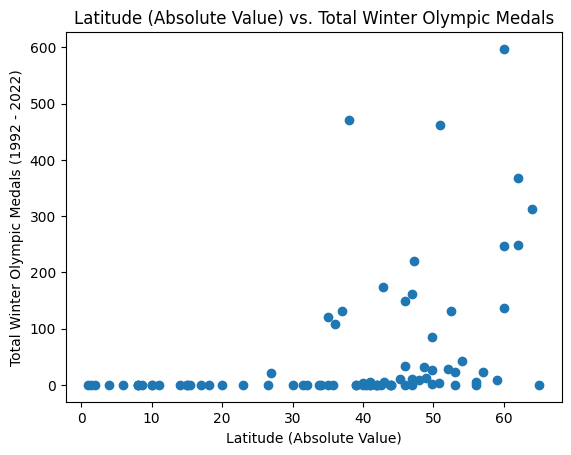

In [16]:
plt.scatter(data["abs_latitude"], data["total_medals"])

plt.xlabel("Latitude (Absolute Value)")
plt.ylabel("Total Winter Olympic Medals (1992 - 2022)")
plt.title ("Latitude (Absolute Value) vs. Total Winter Olympic Medals")

plt.show()

In [45]:
highest_lat = data.loc[data["abs_latitude"].idxmax()]
highest_lat

country               ISL
total_medals            0
gdp_capita        53015.9
abs_latitude         65.0
population      12.641814
Name: 51, dtype: object

Again, we see a strong, positive relationship between countries' distance from the equator and the amount of medals they have won, but, like GDP per capita, it still doesn't fully explain why some countries do better in the Winter Olympics than others. It's interesting to note that two countries with the highest GDP per capita and latitude, Luxembourg and Iceland, respectively, had some of the fewest medals. I don't know much about either country, but I do know that they're both small. Might population be the missing piece in understanding Winter Olympic success?

### Population

Although population was not one of the explanatory variables that I initially hypothesized, it makes sense why it could be impactful: larger countries have larger talent pools to draw from.

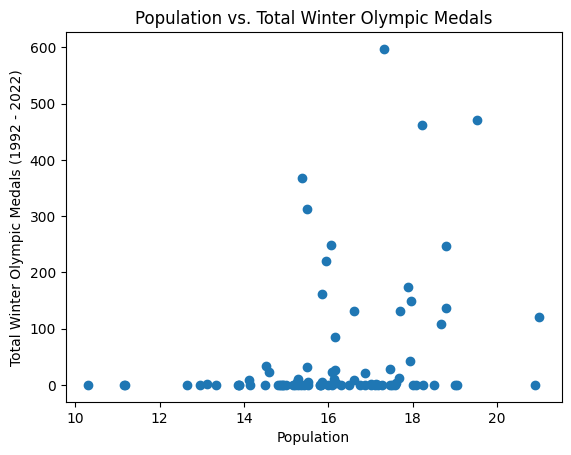

In [17]:
plt.scatter(data["population"], data["total_medals"])

plt.xlabel("Population")
plt.ylabel("Total Winter Olympic Medals (1992 - 2022)")
plt.title ("Population vs. Total Winter Olympic Medals")

plt.show()

Even though there does seem to be a positive relationship between a country's population and the amount of medals it has won, the relationship is not strong enough to claim that population size explains Olympic sucess.

So what is it?

While wealth, cold climate, and population are all associated with stronger Winter Olympic performance, none of these variables alone can fully explain which countries succeed. The most successful nations likely benefit from a combination of all three of these as well as other factors like government investment and winter sports culture. So for any country that's looking to step up its performance at the next Winter Olympics, it's important to not only focus on training individual athletes, but also on driving growth across the country and building a stronger culture around winter sports.